<a href="https://colab.research.google.com/github/Evidence11710/Evi-links-/blob/main/IMDB_Movie_Review_Dataset_Using_Keras_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from tensorflow import keras

from tensorflow.keras import models, layers

In [ ]:
from tensorflow.keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

print("Training samples:", len(train_data))

print("Testing samples:", len(test_data))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [ ]:
def vectorize_sequences(sequences, dimension=10000):

    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):

        results[i, sequence] = 1.

    return results

x_train = vectorize_sequences(train_data)

x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype("float32")

y_test = np.asarray(test_labels).astype("float32")

In [9]:
x_val = x_train[:10000]

partial_x_train = x_train[10000:]

y_val = y_train[:10000]

partial_y_train = y_train[10000:]

In [10]:
model = models.Sequential()

model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))

model.add(layers.Dense(16, activation="relu"))

model.add(layers.Dense(1, activation="sigmoid"))

In [11]:
model.compile(

    optimizer="rmsprop",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [12]:
history = model.fit(

    partial_x_train,

    partial_y_train,

    epochs=20,

    batch_size=512,

    validation_data=(x_val, y_val)

)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7755 - loss: 0.5354 - val_accuracy: 0.8572 - val_loss: 0.4095
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8917 - loss: 0.3346 - val_accuracy: 0.8611 - val_loss: 0.3425
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9161 - loss: 0.2519 - val_accuracy: 0.8829 - val_loss: 0.2936
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9311 - loss: 0.2039 - val_accuracy: 0.8818 - val_loss: 0.2920
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9425 - loss: 0.1717 - val_accuracy: 0.8888 - val_loss: 0.2776
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9524 - loss: 0.1465 - val_accuracy: 0.8824 - val_loss: 0.2891
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9594 - loss: 0.1270 - val_accuracy: 0.8860 - val_loss: 0.2899
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9671 - loss: 0.1104 - val_accuracy: 0.8855 - v

In [13]:
results = model.evaluate(x_test, y_test)

print("Test Loss:", results[0])

print("Test Accuracy:", results[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8594 - loss: 0.6028
Test Loss: 0.6028066873550415
Test Accuracy: 0.8593999743461609


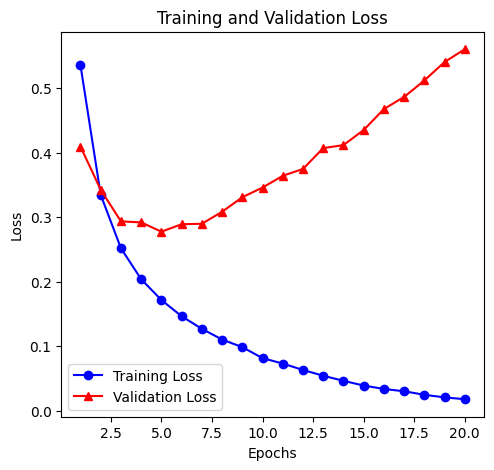

In [14]:
history_dict = history.history

loss = history_dict["loss"]

val_loss = history_dict["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(epochs, loss, "bo-", label="Training Loss")

plt.plot(epochs, val_loss, "r^-", label="Validation Loss")

plt.title("Training and Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

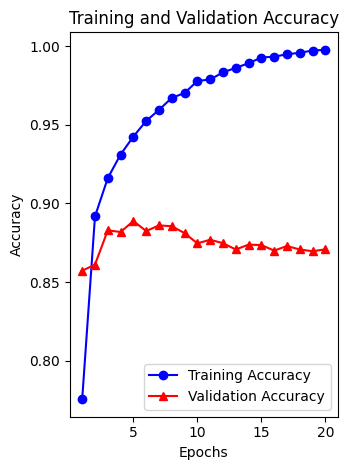

In [15]:
acc = history_dict["accuracy"]

val_acc = history_dict["val_accuracy"]

plt.subplot(1,2,2)

plt.plot(epochs, acc, "bo-", label="Training Accuracy")

plt.plot(epochs, val_acc, "r^-", label="Validation Accuracy")

plt.title("Training and Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.show()